<a href="https://colab.research.google.com/github/liorock1/Partial-SAM-COMP5329/blob/main/PartialSam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partial-SAM — COMP5329
**Vaibhavi Shivanna  ·  Xiaohe Bu · Lior Sabbagh**

---


|| Runs | Section |
|-----|------|---------|
 | | Setup (once) | Sections 1–7 |
|  | Temporal ablation | Section 8 |
| | Structural ablation | Section 9 |
| | Joint ablation | Section 10 |
|  | Download results | Section 11 |

**Before anything:** Runtime → Change runtime type → **T4 GPU** → Save



---
# SECTIONS 1–7 · SHARED SETUP

## Section 1 · GPU Check

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('NO GPU FOUND — go to Runtime > Change runtime type > T4 GPU')

PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


## Section 2 · Imports

In [2]:
import os, csv, time, copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'pandas', 'matplotlib'])
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

print('All imports OK')

All imports OK


## Section 3 · Shared Config

**Do not change these values** — all three experiments must use the same settings.

In [3]:
# ── Shared hyperparameters (do not change) ───────────────────────────
EPOCHS       = 50
BATCH_SIZE   = 128
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
RHO          = 0.05   # SAM perturbation radius (Foret et al. 2021)
SEEDS        = [42]
NUM_CLASSES  = 100

# CIFAR-100 normalisation (Krizhevsky 2009)
CIFAR_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR_STD  = (0.2673, 0.2564, 0.2761)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTDIR = 'results'
os.makedirs(OUTDIR, exist_ok=True)

print(f'Device : {DEVICE}')
print(f'Epochs : {EPOCHS}')
print(f'Seeds  : {SEEDS}')
print(f'Output : {OUTDIR}/')

Device : cuda
Epochs : 50
Seeds  : [42]
Output : results/


## Section 4 · Dataset — CIFAR-100

Source: Krizhevsky (2009), https://www.cs.toronto.edu/~kriz/cifar.html

Downloads automatically (~160 MB, first run only).

In [4]:
def get_dataloaders(batch_size=BATCH_SIZE, num_workers=2):
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    train_set = torchvision.datasets.CIFAR100('./data', train=True,  download=True, transform=train_tf)
    test_set  = torchvision.datasets.CIFAR100('./data', train=False, download=True, transform=test_tf)
    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True)
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader

# Download and verify
train_loader, test_loader = get_dataloaders()
print(f'Train : {len(train_loader.dataset):,} images')
print(f'Test  : {len(test_loader.dataset):,} images')
print(f'Classes: {len(train_loader.dataset.classes)}')

100%|██████████| 169M/169M [00:14<00:00, 11.9MB/s]


Train : 50,000 images
Test  : 10,000 images
Classes: 100


## Section 5 · Model — ResNet-18 for CIFAR-100

Standard CIFAR adaptation (He et al. 2016):
- 3×3 stem conv stride 1 (not 7×7 stride 2)
- No initial max-pool
- Skip connection: H(x) = F(x) + x  [Week 5 tutorial]

In [5]:
def build_model(seed=42):
    """Fresh ResNet-18 for CIFAR-100. Call once per experiment run."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    model = models.resnet18(weights=None, num_classes=NUM_CLASSES)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(DEVICE)

def get_layer_params(model, config):
    """
    Return parameters for specific ResNet-18 residual stages.
    Used by Xiaohe (structural) and Lior (joint).

    config:
        'all4'   -> B1+B2+B3+B4  (full SAM baseline)
        'last2'  -> B3+B4
        'last1'  -> B4 only
        'first1' -> B1 only
        'first2' -> B1+B2
    """
    layer_map = {
        'first1': [model.layer1],
        'first2': [model.layer1, model.layer2],
        'last1':  [model.layer4],
        'last2':  [model.layer3, model.layer4],
        'all4':   [model.layer1, model.layer2, model.layer3, model.layer4],
    }
    return [p for stage in layer_map[config] for p in stage.parameters()]

# Verify
_m = build_model()
n_total = sum(p.numel() for p in _m.parameters())
print(f'ResNet-18 total params: {n_total:,}')
print(f'Output shape: {_m(torch.randn(2,3,32,32).to(DEVICE)).shape}')
print()
print(f'{"Config":<10} {"Perturbed":>12} {"Total":>12} {"% of model":>12}')
print('-' * 50)
for cfg in ['first1','first2','last1','last2','all4']:
    n = sum(p.numel() for p in get_layer_params(_m, cfg))
    print(f'{cfg:<10} {n:>12,} {n_total:>12,} {100*n/n_total:>10.1f}%')
del _m

ResNet-18 total params: 11,220,132
Output shape: torch.Size([2, 100])

Config        Perturbed        Total   % of model
--------------------------------------------------
first1          147,968   11,220,132        1.3%
first2          673,536   11,220,132        6.0%
last1         8,393,728   11,220,132       74.8%
last2        10,493,440   11,220,132       93.5%
all4         11,166,976   11,220,132       99.5%


## Section 6 · Optimizers

- **SAM**: full perturbation over all params (Foret et al. 2021)
- **PartialSAM**: ascent perturbs selected layers only; descent updates all params

In [6]:
class SAM(optim.Optimizer):
    """Full SAM — perturbs all parameters."""
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        """Ascent: w = w + eps_hat"""
        gn = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (gn + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        """Descent: undo perturbation, SGD step using gradient at w+eps_hat"""
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def _grad_norm(self):
        dev = self.param_groups[0]['params'][0].device
        return torch.norm(torch.stack([
            p.grad.norm(p=2).to(dev)
            for group in self.param_groups
            for p in group['params'] if p.grad is not None
        ]), p=2)

    def load_state_dict(self, d):
        super().load_state_dict(d)
        self.base_optimizer.param_groups = self.param_groups


class PartialSAM:
    """Structural Partial-SAM — ascent perturbs selected layers only."""
    def __init__(self, all_params, sam_params, base_cls, rho=0.05, **kwargs):
        self.base_optimizer = base_cls(all_params, **kwargs)
        self.sam_params     = list(sam_params)
        self.rho            = rho

    def zero_grad(self): self.base_optimizer.zero_grad()

    @torch.no_grad()
    def first_step(self):
        grads = [p.grad for p in self.sam_params if p.grad is not None]
        if not grads: return
        gn    = torch.norm(torch.stack([g.norm(p=2) for g in grads]), p=2)
        scale = self.rho / (gn + 1e-12)
        for p in self.sam_params:
            if p.grad is None: continue
            e_w = p.grad * scale
            p.add_(e_w); p._e_w = e_w

    @torch.no_grad()
    def second_step(self):
        for p in self.sam_params:
            if hasattr(p, '_e_w'): p.sub_(p._e_w)
        self.base_optimizer.step()

    def state_dict(self):         return self.base_optimizer.state_dict()
    def load_state_dict(self, d): self.base_optimizer.load_state_dict(d)


print('SAM and PartialSAM defined')

SAM and PartialSAM defined


## Section 7 · Shared Training Utilities

In [7]:
def train_sgd(model, loader, optimizer, criterion):
    """Standard SGD — one forward-backward pass per step."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x); loss = criterion(out, y)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += out.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


def train_sam(model, loader, optimizer, criterion, is_partial=False):
    """Two-pass SAM update. Works for both SAM and PartialSAM."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        # Pass 1: ascent — find eps_hat
        optimizer.zero_grad()
        out = model(x); loss = criterion(out, y); loss.backward()
        if is_partial: optimizer.first_step(); optimizer.zero_grad()
        else:          optimizer.first_step(zero_grad=True)
        # Pass 2: descent — update from w + eps_hat
        out2 = model(x); loss2 = criterion(out2, y); loss2.backward()
        if is_partial: optimizer.second_step()
        else:          optimizer.second_step(zero_grad=True)
        total_loss += loss2.item() * y.size(0)
        correct    += out2.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y  = x.to(DEVICE), y.to(DEVICE)
        out   = model(x); loss = criterion(out, y)
        total_loss += loss.item() * y.size(0)
        correct    += out.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


def measure_sharpness(model, loader, criterion, rho=RHO, n_batches=20):
    """
    rho-sharpness = max_{||eps||<=rho} [L(w+eps) - L(w)]
    Lower = flatter minimum = better generalisation.
    Fixed: separates base loss (no_grad) from gradient computation
    to avoid computation graph errors.
    """
    model.eval()
    base_l, pert_l = [], []
    for i, (x, y) in enumerate(loader):
        if i >= n_batches: break
        x, y = x.to(DEVICE), y.to(DEVICE)

        # Base loss — no grad needed
        with torch.no_grad():
            base_l.append(criterion(model(x), y).item())

        # Fresh forward pass to get gradients for perturbation direction
        model.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()

        # Save weights, apply perturbation
        saved = {n: p.data.clone()
                 for n, p in model.named_parameters() if p.grad is not None}
        gn    = torch.norm(torch.stack(
                    [p.grad.norm() for p in model.parameters()
                     if p.grad is not None]))
        scale = rho / (gn + 1e-12)
        for p in model.parameters():
            if p.grad is not None:
                p.data.add_(p.grad * scale)

        # Perturbed loss — no grad needed
        with torch.no_grad():
            pert_l.append(criterion(model(x), y).item())

        # Restore original weights
        for n, p in model.named_parameters():
            if n in saved: p.data.copy_(saved[n])
        model.zero_grad()

    return max(0.0, sum(pert_l)/len(pert_l) - sum(base_l)/len(base_l))

def save_row(row, filename):
    """Append one result row to a CSV file."""
    path   = os.path.join(OUTDIR, filename)
    exists = os.path.isfile(path)
    with open(path, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if not exists: w.writeheader()
        w.writerow(row)


def save_history(history, name):
    """Save per-epoch training history to CSV."""
    path = os.path.join(OUTDIR, f'history_{name}.csv')
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=history[0].keys())
        w.writeheader(); w.writerows(history)


print('All shared utilities defined')
print('Setup complete — scroll to your section and start running')

All shared utilities defined
Setup complete — scroll to your section and start running


---
# SECTION 10  — Joint Ablation
**Combine best temporal + best structural settings from Sections 8 & 9.**

| Config | alpha | Layers | Description |
|--------|-------|--------|-------------|
| Joint-A | 0.25 | first1 | Expected Pareto-optimal |
| Joint-B | 0.25 | first2 | Lighter structural |



---

In [8]:
def run_joint(alpha, layers_config, seed):
    """
    Joint Partial-SAM experiment.
    Combines temporal schedule (alpha) + structural sparsity (layers_config).
    Phase 1 (epoch < T*(1-alpha)): pure SGD
    Phase 2 (epoch >= T*(1-alpha)): PartialSAM on selected layers
    """
    sam_start = int(EPOCHS * (1.0 - alpha))
    label     = f'joint_a{alpha}_l{layers_config}_s{seed}'
    criterion = nn.CrossEntropyLoss()

    print(f"\n{'='*60}")
    print(f"JOINT | alpha={alpha} | layers={layers_config} | seed={seed}")
    print(f"SAM starts epoch {sam_start}, perturbing {layers_config} only")
    print(f"{'='*60}")

    model      = build_model(seed)
    sgd_kwargs = dict(lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    sgd_opt    = optim.SGD(model.parameters(), **sgd_kwargs)

    sam_p      = get_layer_params(model, layers_config)
    n_pert     = sum(p.numel() for p in sam_p)
    n_total    = sum(p.numel() for p in model.parameters())
    print(f"  Perturbed layers: {n_pert:,} / {n_total:,} ({100*n_pert/n_total:.1f}%)")

    partial_opt = PartialSAM(list(model.parameters()), sam_p,
                             optim.SGD, rho=RHO, **sgd_kwargs)
    scheduler   = optim.lr_scheduler.CosineAnnealingLR(sgd_opt, T_max=EPOCHS)

    history = []; best_acc = 0.0; best_state = None

    for epoch in range(1, EPOCHS + 1):
        t0      = time.time()
        use_sam = epoch > sam_start
        if use_sam:
            tr_loss, tr_acc = train_sam(model, train_loader, partial_opt, criterion, is_partial=True)
        else:
            tr_loss, tr_acc = train_sgd(model, train_loader, sgd_opt, criterion)
        _, te_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        history.append({'epoch': epoch, 'phase': 'PARTIAL_SAM' if use_sam else 'SGD',
                         'train_acc': round(tr_acc*100,2), 'test_acc': round(te_acc*100,2)})
        if te_acc > best_acc: best_acc = te_acc; best_state = copy.deepcopy(model.state_dict())
        if epoch % 40 == 0 or epoch == 1 or epoch == sam_start + 1:
            tag = '[PARTIAL-SAM]' if use_sam else '[SGD]'
            print(f"  Epoch {epoch:3d}/{EPOCHS} {tag}  train {tr_acc*100:.1f}%  test {te_acc*100:.1f}%  ({time.time()-t0:.0f}s)")

    model.load_state_dict(best_state)
    _, final_acc = evaluate(model, test_loader, criterion)
    print('  Measuring sharpness...')
    sharpness = measure_sharpness(model, train_loader, criterion)

    sam_eps     = EPOCHS - sam_start
    struct_frac = n_pert / n_total
    total_cost  = sam_start * 1 + sam_eps * (1 + struct_frac)
    flops_saved = round((1 - total_cost / (EPOCHS * 2)) * 100, 1)

    row = {'alpha': alpha, 'layers': layers_config, 'seed': seed,
           'test_acc': round(final_acc*100,2),
           'sharpness': round(sharpness,4),
           'flops_saved': flops_saved}
    save_row(row, 'results_joint.csv')
    save_history(history, label)
    print(f"  Done — acc={final_acc*100:.2f}%  sharp={sharpness:.4f}  flops_saved={flops_saved}%")
    return row

print('run_joint() defined')

run_joint() defined


In [10]:
# ── LIOR: Run this cell ──────────────────────────────────────────────

JOINT_CONFIGS = [
    (0.25, 'first1'),  # Joint-A: expected Pareto-optimal
    (0.25, 'first2'),  # Joint-B: lighter structural
    # (0.10, 'last2'),  # Joint-C: lighter temporal
]

done_j = set()
j_csv  = os.path.join(OUTDIR, 'results_joint.csv')
if os.path.exists(j_csv):
    df_done = pd.read_csv(j_csv)
    for _, r in df_done.iterrows():
        done_j.add((float(r['alpha']), str(r['layers']), int(r['seed'])))
    print(f'Already done: {len(done_j)} runs — skipping them')

joint_runs = [(a,l,s) for a,l in JOINT_CONFIGS for s in SEEDS if (a,l,s) not in done_j]
print(f'{len(joint_runs)}/{len(JOINT_CONFIGS)*len(SEEDS)} runs remaining (~{len(joint_runs)*25} min)\n')

for alpha, layers, seed in joint_runs:
    run_joint(alpha, layers, seed)

print('\nAll joint runs complete!')

2/2 runs remaining (~50 min)


JOINT | alpha=0.25 | layers=first1 | seed=42
SAM starts epoch 37, perturbing first1 only
  Perturbed layers: 147,968 / 11,220,132 (1.3%)
  Epoch   1/50 [SGD]  train 9.4%  test 14.5%  (46s)
  Epoch  38/50 [PARTIAL-SAM]  train 56.3%  test 56.3%  (85s)
  Epoch  40/50 [PARTIAL-SAM]  train 66.5%  test 58.8%  (86s)
  Measuring sharpness...
  Done — acc=71.52%  sharp=0.2332  flops_saved=49.8%

JOINT | alpha=0.25 | layers=first2 | seed=42
SAM starts epoch 37, perturbing first2 only
  Perturbed layers: 673,536 / 11,220,132 (6.0%)
  Epoch   1/50 [SGD]  train 9.5%  test 15.0%  (45s)
  Epoch  38/50 [PARTIAL-SAM]  train 55.8%  test 55.7%  (86s)
  Epoch  40/50 [PARTIAL-SAM]  train 66.2%  test 59.6%  (86s)
  Measuring sharpness...
  Done — acc=71.05%  sharp=0.2327  flops_saved=49.2%

All joint runs complete!


---
# SECTION 11 · DOWNLOAD RESULTS
---

In [11]:
from google.colab import files

print('Downloading all results files...')
for fname in os.listdir(OUTDIR):
    if fname.endswith('.csv'):
        print(f'  {fname}')
        files.download(os.path.join(OUTDIR, fname))

print('\nDone! Rename your CSV before sharing:')
print('  Vaibhavi -> results_temporal_vaibhavi.csv')
print('  Xiaohe   -> results_structural_xiaohe.csv')
print('  Lior     -> results_joint_lior.csv')

  history_joint_a0.25_lfirst2_s42.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  results_joint.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  history_joint_a0.25_lfirst1_s42.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Rename your CSV before sharing:
  Vaibhavi -> results_temporal_vaibhavi.csv
  Xiaohe   -> results_structural_xiaohe.csv
  Lior     -> results_joint_lior.csv


---
# SECTION 12 — Generate All Tables + Figures
**Run after collecting all three CSVs**

Generates: Table 1, Table 2, Table 3, Figure 1 (Pareto), Figure 2 (structural bar), Figure 3 (temporal bar)

---

In [13]:
# Upload all three CSVs first, then run this cell ────────────
# from google.colab import files
# files.upload()  # upload results_temporal.csv, results_structural.csv, results_joint.csv

df_t = pd.read_csv(os.path.join(OUTDIR, 'results_temporal.csv'))
df_s = pd.read_csv(os.path.join(OUTDIR, 'results_structural.csv'))
df_j = pd.read_csv(os.path.join(OUTDIR, 'results_joint.csv'))

# ── TABLE 1: Temporal ablation ────────────────────────────────────────
agg_t = df_t.groupby('alpha').agg(
    acc_mean=('test_acc','mean'), acc_std=('test_acc','std'),
    sharp_mean=('sharpness','mean'), flops_saved=('flops_saved','first')
).reset_index()

print('=' * 70)
print('TABLE 1: Temporal Ablation  (all4 layers, ResNet-18, CIFAR-100)')
print('=' * 70)
print(f'{"Config":<22} {"Acc (%)":>15}  {"rho-Sharp":>11}  {"FLOPs saved":>12}')
print('-' * 70)
labels_t = {0.0:'SGD (alpha=0)', 0.10:'alpha=0.10', 0.25:'alpha=0.25',
             0.50:'alpha=0.50', 1.00:'Full SAM (alpha=1.0)'}
for _, r in agg_t.sort_values('alpha').iterrows():
    lbl = labels_t.get(r['alpha'], f'alpha={r["alpha"]}')
    print(f"{lbl:<22} {r['acc_mean']:>6.2f} +/- {r['acc_std']:>4.2f}  {r['sharp_mean']:>9.4f}  {r['flops_saved']:>10.1f}%")

# ── TABLE 2: Structural ablation ──────────────────────────────────────
order_s = ['SGD','first1','first2','last1','last2','all4']
agg_s   = df_s.groupby('layers').agg(
    acc_mean=('test_acc','mean'), acc_std=('test_acc','std'),
    sharp_mean=('sharpness','mean'), flops_saved=('flops_saved','first')
).reindex([o for o in order_s if o in df_s['layers'].values]).reset_index()

print('\n' + '=' * 70)
print('TABLE 2: Structural Ablation  (alpha=1.0, ResNet-18, CIFAR-100)')
print('=' * 70)
print(f'{"Config":<22} {"Acc (%)":>15}  {"rho-Sharp":>11}  {"FLOPs saved":>12}')
print('-' * 70)
labels_s = {'SGD':'SGD (no SAM)','first1':'First-1 (B1)','first2':'First-2 (B1+B2)',
             'last1':'Last-1 (B4)','last2':'Last-2 (B3+B4)','all4':'All-4 (Full SAM)'}
for _, r in agg_s.iterrows():
    lbl = labels_s.get(r['layers'], r['layers'])
    print(f"{lbl:<22} {r['acc_mean']:>6.2f} +/- {r['acc_std']:>4.2f}  {r['sharp_mean']:>9.4f}  {r['flops_saved']:>10.1f}%")

# ── TABLE 3: Joint ablation ───────────────────────────────────────────
agg_j = df_j.groupby(['alpha','layers']).agg(
    acc_mean=('test_acc','mean'), acc_std=('test_acc','std'),
    flops_saved=('flops_saved','first')
).reset_index()

print('\n' + '=' * 70)
print('TABLE 3: Joint Ablation  (ResNet-18, CIFAR-100)')
print('=' * 70)
print(f'{"Config":<30} {"Acc (%)":>15}  {"FLOPs saved":>12}')
print('-' * 70)
for _, r in agg_j.iterrows():
    lbl = f'alpha={r["alpha"]}, {r["layers"]}'
    print(f"{lbl:<30} {r['acc_mean']:>6.2f} +/- {r['acc_std']:>4.2f}  {r['flops_saved']:>10.1f}%")

print('\nTables printed!')

TABLE 1: Temporal Ablation  (all4 layers, ResNet-18, CIFAR-100)
Config                         Acc (%)    rho-Sharp   FLOPs saved
----------------------------------------------------------------------
SGD (alpha=0)           75.71 +/-  nan     0.0929        50.0%
alpha=0.25              71.85 +/-  nan     0.2083        37.0%
Full SAM (alpha=1.0)    64.10 +/-  nan     0.2033         0.0%

TABLE 2: Structural Ablation  (alpha=1.0, ResNet-18, CIFAR-100)
Config                         Acc (%)    rho-Sharp   FLOPs saved
----------------------------------------------------------------------
SGD (no SAM)            72.19 +/-  nan     0.1914        50.0%
First-1 (B1)            71.65 +/-  nan     0.1845        49.3%
First-2 (B1+B2)         71.04 +/-  nan     0.1784        47.0%
Last-1 (B4)             71.55 +/-  nan     0.2043        12.6%
Last-2 (B3+B4)          71.59 +/-  nan     0.1887         3.2%
All-4 (Full SAM)        71.75 +/-  nan     0.1749         0.2%

TABLE 3: Joint Ablation  (Res

Figure 1 (Pareto) saved


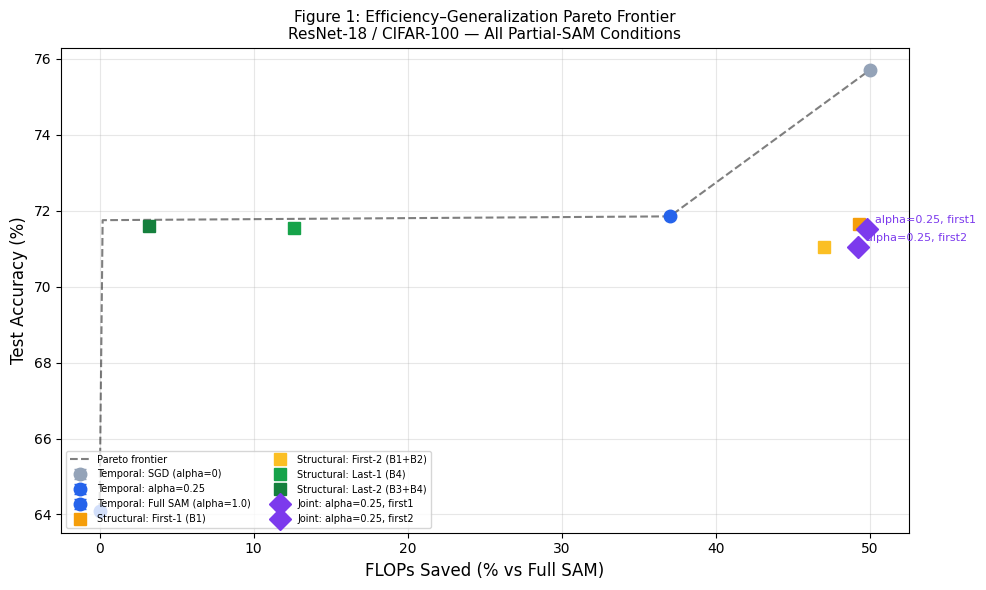

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# ── FIGURE 1: Pareto Frontier (all experiments combined) ─────────────

fig, ax = plt.subplots(figsize=(10, 6))

# Temporal points
for _, r in agg_t.iterrows():
    col = '#94a3b8' if r['alpha']==0 else '#2563EB'
    lbl = labels_t.get(r['alpha'], str(r['alpha']))
    ax.errorbar(r['flops_saved'], r['acc_mean'], yerr=r['acc_std'],
                fmt='o', color=col, markersize=9, capsize=4, linewidth=1.5,
                label=f'Temporal: {lbl}', zorder=3)

# Structural points
colors_s = {'SGD':'#94a3b8','first1':'#F59E0B','first2':'#FBBF24',
             'last1':'#16A34A','last2':'#15803D','all4':'#2563EB'}
for _, r in agg_s.iterrows():
    if r['layers'] in ['SGD','all4']: continue  # already in temporal
    lbl = labels_s.get(r['layers'], r['layers'])
    ax.errorbar(r['flops_saved'], r['acc_mean'], yerr=r['acc_std'],
                fmt='s', color=colors_s.get(r['layers'],'#888'),
                markersize=9, capsize=4, linewidth=1.5,
                label=f'Structural: {lbl}', zorder=3)

# Joint points
for _, r in agg_j.iterrows():
    lbl = f'Joint: alpha={r["alpha"]}, {r["layers"]}'
    ax.errorbar(r['flops_saved'], r['acc_mean'], yerr=r['acc_std'],
                fmt='D', color='#7C3AED', markersize=11, capsize=4,
                linewidth=2, label=lbl, zorder=4)
    ax.annotate(lbl.replace('Joint: ',''), (r['flops_saved'], r['acc_mean']),
                textcoords='offset points', xytext=(6,4), fontsize=8, color='#7C3AED')

# Pareto frontier
all_pts = ([(r['flops_saved'], r['acc_mean']) for _, r in agg_t.iterrows()] +
           [(r['flops_saved'], r['acc_mean']) for _, r in agg_s.iterrows()] +
           [(r['flops_saved'], r['acc_mean']) for _, r in agg_j.iterrows()])
all_pts.sort(key=lambda p: p[0])
pareto = []
best_y = -1
for x, y in all_pts:
    if y > best_y:
        best_y = y; pareto.append((x, y))
if pareto:
    px, py = zip(*pareto)
    ax.plot(px, py, 'k--', linewidth=1.5, alpha=0.5, label='Pareto frontier', zorder=2)

ax.set_xlabel('FLOPs Saved (% vs Full SAM)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Figure 1: Efficiency–Generalization Pareto Frontier\nResNet-18 / CIFAR-100 — All Partial-SAM Conditions', fontsize=11)
ax.legend(fontsize=7, loc='lower left', ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure1_pareto.png'), dpi=150, bbox_inches='tight')
print('Figure 1 (Pareto) saved')
plt.show()

from google.colab import files
files.download(os.path.join(OUTDIR, 'figure1_pareto.png'))